# 02 — Baseline

**Anterior:** `01_eda.ipynb` | **Projeto:** ver `PLANNING.md`

**Objetivos:**

1. Aplicar o tratamento de dados definido na EDA;
2. Fixar o protocolo de validação usado em todas as comparações do projeto;
3. Estabelecer pisos de referência (classificadores triviais) e o baseline real (TF-IDF + Regressão Logística), que passa a ser o critério de adoção de qualquer mudança nos notebooks seguintes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 110,
})

RANDOM_STATE = 42

## 1. Preparação dos dados

Tratamento definido na EDA (seção 2.1): deduplicação do train por texto (primeira ocorrência) e remoção dos textos presentes no test; test intacto. A limpeza é implementada como função para migração direta ao código de produção (`src/train.py`).

In [2]:
def load_and_clean(data_dir: str = "../data/raw"):
    """Carrega os CSVs e aplica o tratamento definido na EDA (notebook 01)."""
    train = pd.read_csv(f"{data_dir}/medical_tc_train.csv")
    test = pd.read_csv(f"{data_dir}/medical_tc_test.csv")

    n0 = len(train)
    train = train.drop_duplicates(subset="medical_abstract", keep="first")
    n1 = len(train)
    train = train[~train["medical_abstract"].isin(set(test["medical_abstract"]))]
    n2 = len(train)

    print(f"train original:       {n0:,}")
    print(f"após dedup:           {n1:,}  (-{n0 - n1:,})")
    print(f"após remover overlap: {n2:,}  (-{n1 - n2:,})")
    print(f"test (intacto):       {len(test):,}")
    return train.reset_index(drop=True), test


train, test = load_and_clean()

labels = pd.read_csv("../data/raw/medical_tc_labels.csv")
label_map = dict(zip(labels["condition_label"], labels["condition_name"]))

X_train = train["medical_abstract"]
y_train = train["condition_label"]

print("\nDistribuição das classes após limpeza (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))

train original:       11,550
após dedup:           9,445  (-2,105)
após remover overlap: 8,457  (-988)
test (intacto):       2,888

Distribuição das classes após limpeza (%):
condition_label
1    24.2
2     9.3
3    12.8
4    22.1
5    31.6
Name: proportion, dtype: float64


## 2. Protocolo de validação

Fixo para todas as comparações do projeto:

- **StratifiedKFold, 5 folds**, `shuffle=True`, semente 42 — estratificação preserva as proporções de classe em cada fold;
- **Métrica primária: F1 macro** (média ± desvio-padrão entre folds); accuracy reportada como contexto;
- **Critério de adoção de mudanças:** superação consistente da referência, além do desvio entre folds;
- **Test set reservado** à avaliação final (notebook 04).

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["f1_macro", "accuracy"]


def evaluate(model, name: str, results: dict):
    """Validação cruzada sob o protocolo padrão; acumula resultados em `results`."""
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    results[name] = {
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "accuracy": scores["test_accuracy"].mean(),
        "fit_s": scores["fit_time"].mean(),
    }
    r = results[name]
    print(f"{name:<28} F1 macro: {r['f1_macro']:.3f} ± {r['f1_macro_std']:.3f}"
          f" | accuracy: {r['accuracy']:.3f} | fit: {r['fit_s']:.1f}s")


results = {}

## 3. Pisos de referência

`DummyClassifier` nas estratégias `most_frequent` (classe majoritária) e `stratified` (sorteio proporcional). Servem como verificação de sanidade do pipeline e como demonstração da inadequação da accuracy isolada neste dataset.

In [4]:
from sklearn.dummy import DummyClassifier

evaluate(DummyClassifier(strategy="most_frequent"), "Dummy (most_frequent)", results)
evaluate(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
         "Dummy (stratified)", results)

Dummy (most_frequent)        F1 macro: 0.096 ± 0.000 | accuracy: 0.316 | fit: 0.0s


Dummy (stratified)           F1 macro: 0.200 ± 0.007 | accuracy: 0.235 | fit: 0.0s


## 4. Baseline — TF-IDF + Regressão Logística

Justificativa: representação TF-IDF é adequada ao perfil dos textos (EDA, seções 4-5); Regressão Logística é eficiente em features esparsas de alta dimensão, fornece probabilidades nativas (requisito da futura API) e coeficientes interpretáveis. `class_weight="balanced"` conforme decisão da EDA.

Vetorizador e classificador são encapsulados em `Pipeline`, de modo que o TF-IDF seja re-ajustado apenas no treino de cada fold — evitando contaminação das estatísticas de IDF pelos folds de validação.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", min_df=5)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                               random_state=RANDOM_STATE)),
])

evaluate(baseline, "TF-IDF + LogReg", results)

TF-IDF + LogReg              F1 macro: 0.717 ± 0.002 | accuracy: 0.721 | fit: 0.6s


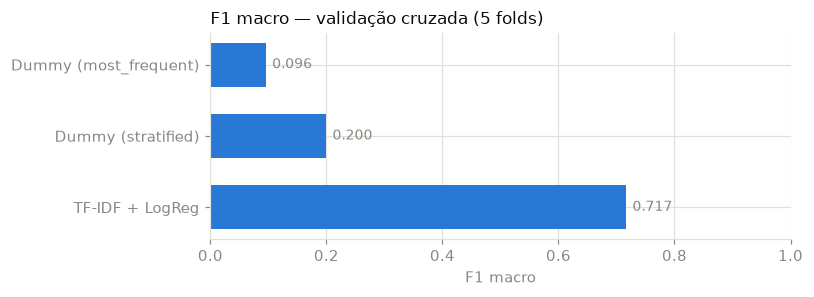

,f1_macro,f1_macro_std,accuracy,fit_s
Dummy (most_frequent),0.096,0.000,0.316,0.008
Dummy (stratified),0.200,0.007,0.235,0.007
TF-IDF + LogReg,0.717,0.002,0.721,0.593


In [6]:
summary = pd.DataFrame(results).T[["f1_macro", "f1_macro_std", "accuracy", "fit_s"]].round(3)

fig, ax = plt.subplots(figsize=(7.5, 2.8))
names = list(summary.index)[::-1]
vals = summary["f1_macro"][::-1]
bars = ax.barh(names, vals, color=BLUE, height=0.62)
ax.bar_label(bars, fmt="%.3f", fontsize=9, color=MUTED, padding=4)
ax.set_title("F1 macro — validação cruzada (5 folds)", loc="left", fontsize=11)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 macro")
plt.tight_layout()
plt.show()

summary

**Achados:** o baseline supera os pisos com ampla margem (0.717 vs 0.096/0.200), validando a sanidade do pipeline. O contraste do `most_frequent` (accuracy 0.316, F1 macro 0.096) confirma empiricamente a escolha do F1 macro como métrica primária. **A referência do projeto passa a ser F1 macro = 0.717 ± 0.002**; dado o desvio reduzido, diferenças acima de ~0.005 são distinguíveis de ruído.

## 5. Desempenho por classe

Predições out-of-fold (`cross_val_predict`): cada amostra é predita pelo modelo do fold em que atuou como validação, permitindo um relatório por classe sem uso do test set.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred_cv = cross_val_predict(baseline, X_train, y_train, cv=cv, n_jobs=-1)

print(classification_report(
    y_train, y_pred_cv,
    target_names=[label_map[i] for i in sorted(label_map)],
    digits=3,
))

                                 precision    recall  f1-score   support

                      neoplasms      0.821     0.826     0.823      2044
      digestive system diseases      0.635     0.769     0.696       784
        nervous system diseases      0.600     0.710     0.651      1086
        cardiovascular diseases      0.787     0.815     0.800      1873
general pathological conditions      0.678     0.566     0.617      2670

                       accuracy                          0.721      8457
                      macro avg      0.704     0.737     0.717      8457
                   weighted avg      0.723     0.721     0.719      8457



## 6. Síntese

1. **Dados:** train de 11.550 → 8.457 exemplos após dedup (−2.105) e remoção da sobreposição com o test (−988); desbalanceamento preservado (31,6% vs 9,3%).
2. **Referência estabelecida: F1 macro = 0.717 ± 0.002** (TF-IDF + LogReg; fit ~0.7s/fold), muito acima dos pisos (0.096 / 0.200).
3. **Hipótese da EDA confirmada nas predições out-of-fold:** `general pathological conditions` tem o pior F1 (0.617; recall 0.566) — as classes específicas absorvem seus exemplos. `neoplasms` (0.823) e `cardiovascular` (0.800) são as mais fortes.
4. **Contexto:** considerando o teto de ambiguidade multi-label documentado na EDA, 0.717 é um baseline sólido para 5 classes.

**Próximo:** `03_feature_engineering.ipynb` — variações de representação e ablação dos textos ambíguos, avaliadas contra a referência de 0.717.